## **Curve fitting to the Cross Model**

**Problem 6** The data below is for an iron oxide suspension similar to that used by Imation (http://www.imation.com/en/) to make the magnetic data storage coatings on tapes and floppy disks. Plot the data as viscosity vs. shear rate and fit it to the Cross model parameters.
<br><br>

Cross Model: 

$$\eta = \eta_{\infty} + \frac{\eta_0 - \eta_{\infty}}{1 + (k \cdot \dot{\gamma})^n}$$

### **Remarks**

Cross Model(written above) has 4 parameters.

- $\eta_0$ : Viscosity at zero-shear rate
- $\eta_{\infty}$ : Viscosity at infinite-shear rate
- $n$ : Flow behavior index, or *Power Index*
- $k$ : Consistency time constant, or simply *Time Constant*

and through Optimization we can find the best parameters for the data given. 
<br><br>

#### *First, let's plot the Shear Rate vs. Viscosity data.*


,Shear Rate (1/s),Viscosity (Pa.s)
0,0.000005,70000.00
1,0.000010,60000.00
2,0.000019,55000.00
3,0.000450,2500.00
4,0.001000,1400.00
5,0.007000,200.00
6,0.400000,3.00
7,1.600000,1.50
8,6.000000,0.45
9,10.000000,0.32


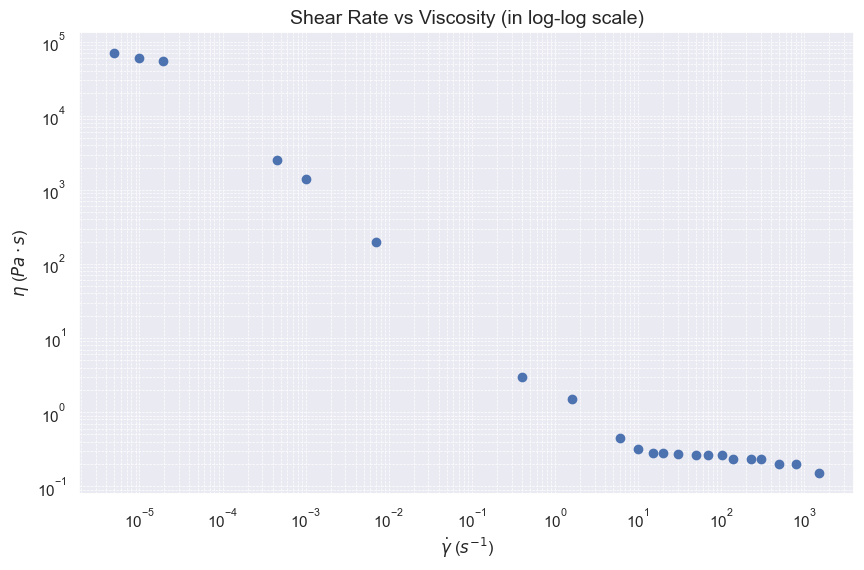

In [10]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="darkgrid")

x = [0.000005, 0.00001, 0.000019, 0.00045, 0.001, 0.007, 0.4, 1.6, 6, 10, 15, 20, 30, 50, 70, 101, 140, 230, 300, 500, 800, 1500]
y = [70000, 60000, 55000, 2500, 1400, 200, 3, 1.5, 0.45, 0.32, 0.28, 0.28, 0.27, 0.26, 0.26, 0.26, 
     0.23, 0.23, 0.23, 0.2, 0.2, 0.15]

data = pd.DataFrame({'Shear Rate (1/s)': x, 'Viscosity (Pa.s)': y})
display(data.head(10))

# plot x,y data
plt.figure(figsize=(10, 6))
plt.plot(data['Shear Rate (1/s)'], data['Viscosity (Pa.s)'], marker='o', linestyle='', color='b')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\dot{\gamma}$ ($s^{-1}$)')
plt.ylabel('$\eta$ ($Pa \cdot s$)')
plt.title('Shear Rate vs Viscosity (in log-log scale)', fontsize=14)
plt.grid(True, which="both", ls="--", linewidth=0.5)

#### *And through Optimization we can find the best parameters for the data given.*

### **Optimization**

First define the Cross Model(`cross_model`) and Loss Function as MSE.

$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2$$

and by minimizing MSE(or, the Loss Function) the model will be closer and closer to the given (or, Experimental) data. 
<br><br>

In the code below we use `scipy.optimize.minimize()` and `method='L-BFGS-B` to minimize the Loss Function and estimating parameters for the fitted model.

By `'L-BFGS-B'` algorithm the optimization terminates when further reduction of the loss function becomes negligible.

$$\nabla L(\theta) \approx 0$$

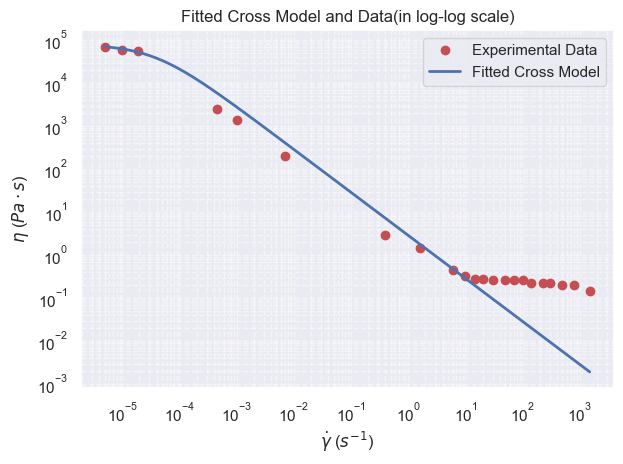

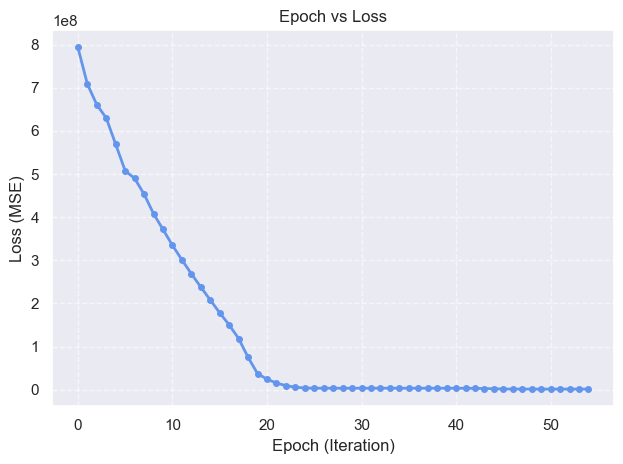

--- Optimized Cross Model Parameters ---
eta_0:   79352.2285 Pa·s
eta_inf: 0.0000 Pa·s
k:       27462.2674 s
n:       1.0000


In [8]:
from scipy.optimize import minimize
import warnings
warnings.filterwarnings(action = 'ignore')

# Defining the Cross Model and Objective Function 
def cross_model(shear_rate, eta_0, eta_inf, k, n):
    return eta_inf + (eta_0 - eta_inf) / (1 + (k * shear_rate) ** n)

def loss_function(params, x, y):
    eta_0, eta_inf, k, n = params
    y_pred = cross_model(x, eta_0, eta_inf, k, n)
    return np.mean((y - y_pred) ** 2)

x_data = data['Shear Rate (1/s)'].values
y_data = data['Viscosity (Pa.s)'].values

# Tracking Loss History 
loss_history = []
def tracking_callback(current_params):
    current_loss = loss_function(current_params, x_data, y_data)
    loss_history.append(current_loss)

## Model Fitting
initial_guesses = [y_data.max(), y_data.min(), 1.0, 0.5]          # Set Initial Guesses
bounds = [(0, np.inf), (0, np.inf), (0, np.inf), (0, 1.0)]
loss_history.append(loss_function(initial_guesses, x_data, y_data))

# Model Optimization 
optimization_result = minimize(fun=loss_function, x0=initial_guesses,args=(x_data, y_data),
                               bounds=bounds, method='L-BFGS-B', callback=tracking_callback)
eta_0_opt, eta_inf_opt, k_opt, n_opt = optimization_result.x


x_smooth = np.logspace(np.log10(x_data.min()), np.log10(x_data.max()), 500)
y_smooth_pred = cross_model(x_smooth, eta_0_opt, eta_inf_opt, k_opt, n_opt)

# Plotting Fitted Model vs Data
plt.loglog(x_data, y_data, 'ro', label='Experimental Data', markersize=6)
plt.loglog(x_smooth, y_smooth_pred, 'b-', label='Fitted Cross Model', linewidth=2)
plt.xlabel('$\dot{\gamma}$ ($s^{-1}$)')
plt.ylabel('$\eta$ ($Pa \cdot s$)')
plt.title('Fitted Cross Model and Data(in log-log scale)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig('cross_model_fit.png', dpi=300)
plt.show() 

# Epoch vs Loss Graph
epochs = np.arange(0, len(loss_history))
plt.plot(epochs, loss_history, 'g-o', linewidth=2, markersize=4, color='cornflowerblue')
plt.xlabel('Epoch (Iteration)')
plt.ylabel('Loss (MSE)')
plt.title('Epoch vs Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('fitting_loss_history.png', dpi=300)
plt.show()

# Optimized Parameters 
print("--- Optimized Cross Model Parameters ---")
print(f"eta_0:   {eta_0_opt:.4f} Pa·s")
print(f"eta_inf: {eta_inf_opt:.4f} Pa·s")
print(f"k:       {k_opt:.4f} s")
print(f"n:       {n_opt:.4f}")

The Optimized 4 parameters are shown above. 

#### **Graph 1**: Fitted Cross Model and Data(in log-log scale)

: This graph shows the optimized Cross Model (shown as blue lineplot) and the Experimental Data (plotted red)

#### **Graph 2**: Epoch vs Loss

: This graph shows the decrease of the Loss Function(or, MSE) over the Iteration

 You can easily see that the graph is decreasing smoothly as the model is getting fitted. 